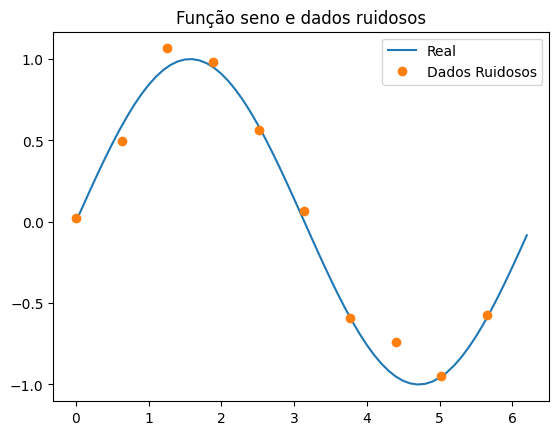

0
[[0.0342722]]


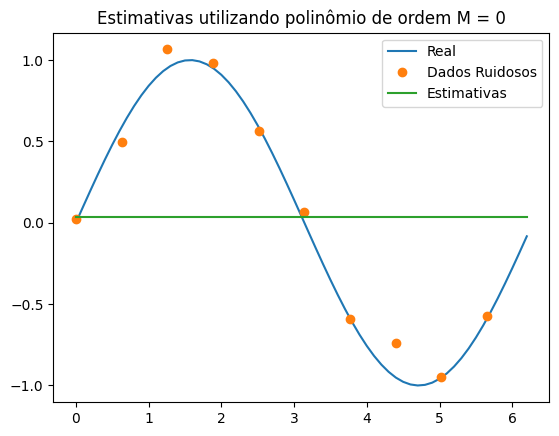

1
[[ 0.84578117 -0.28701259]]


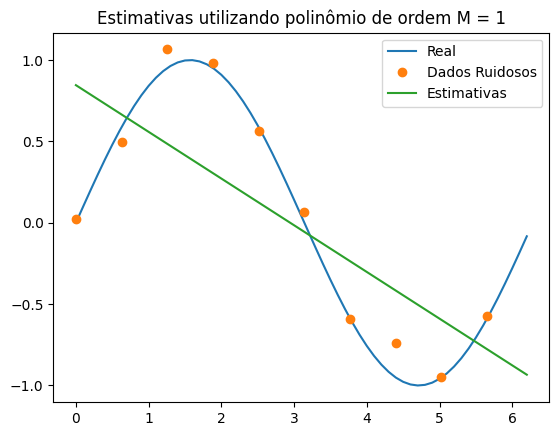

2
[[ 0.47033119  0.16114782 -0.07925216]]


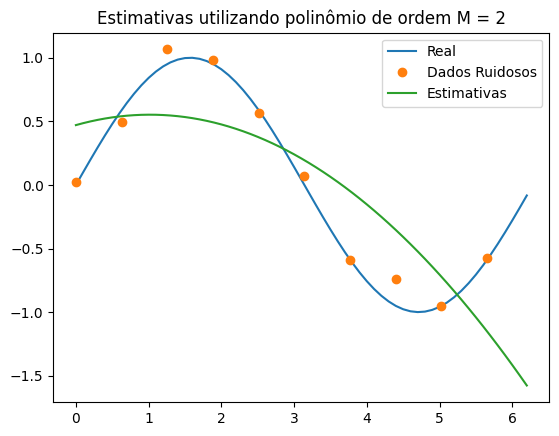

3
[[-0.08318475  1.77272329 -0.8303623   0.08855029]]


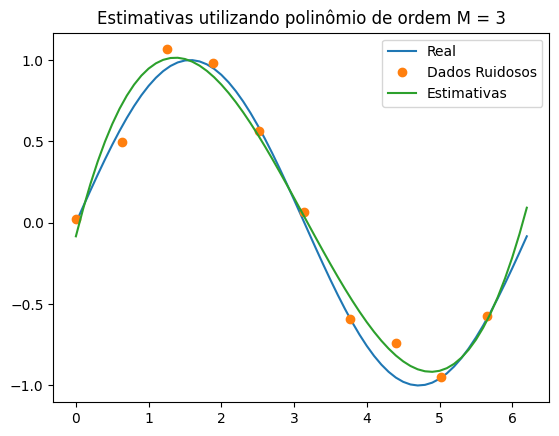

4
[[-0.03846938  1.47619527 -0.56555208  0.01343886  0.00664131]]


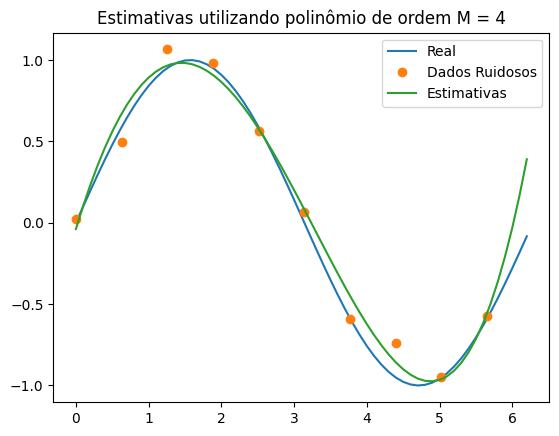

5
[[ 0.00374994  0.79604124  0.43703664 -0.48771956  0.10822478 -0.00718556]]


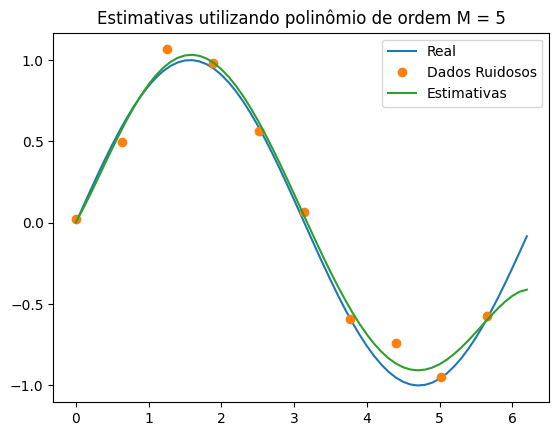

6
[[ 0.02141594 -0.03760718  2.25581408 -1.87204724  0.58130045 -0.08160094
   0.00438651]]


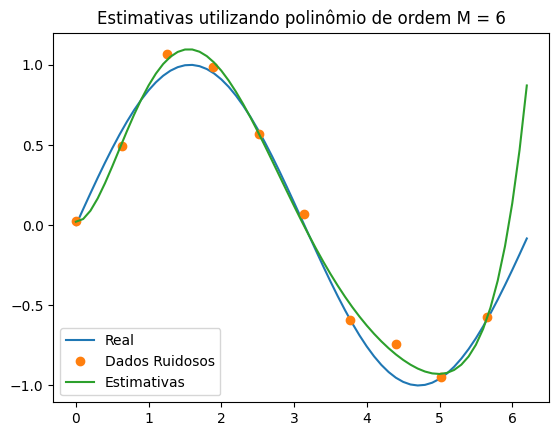

7
[[ 2.10129851e-02  3.94522181e-02  2.03095637e+00 -1.63624471e+00
   4.63393863e-01 -5.11948916e-02  4.84407709e-04  1.97155174e-04]]


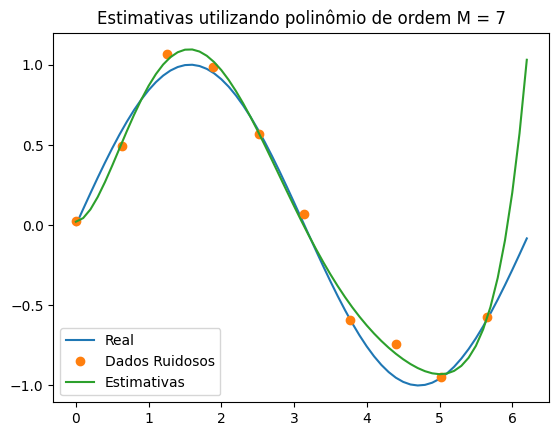

8
[[ 2.34483650e-02 -3.04271013e+00  1.30225891e+01 -1.62971142e+01
   1.02438754e+01 -3.65199105e+00  7.43371733e-01 -8.02342666e-02
   3.55584954e-03]]


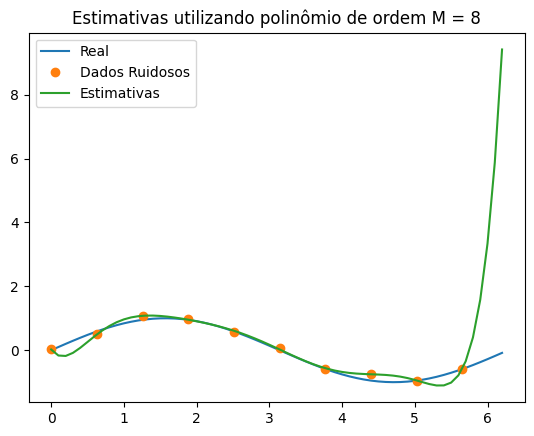

9
[[ 2.31021013e-02  3.34969660e+00 -1.30882753e+01  2.52936369e+01
  -2.43082744e+01  1.29943587e+01 -4.07679304e+00  7.46533300e-01
  -7.37970226e-02  3.03977579e-03]]


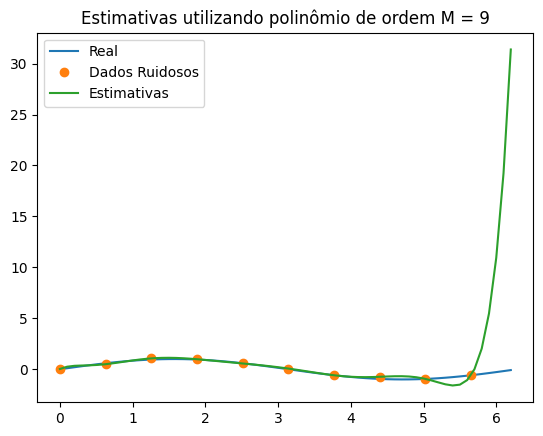

Lista de Erros por modelo (grau do polinomio)
[4.79205391e-01 2.10908542e-01 1.59222222e-01 1.02007081e-02
 8.43574865e-03 4.57372747e-03 2.28508670e-03 2.27923897e-03
 5.82950728e-04 2.92555619e-18]


In [ ]:

import numpy as np
from matplotlib import pyplot as plt

x = np.arange(0,2*np.pi,0.1)   # start,stop,step [0, 0.1, 0.2, 0.3, 0.4 ... 6.28]
y = np.sin(x)  # função seno



xn = np.arange(0,2*np.pi,2*np.pi/10) # Gerando 10 pontos entre 0 e 2*pi*x
yn = np.sin(xn) + np.random.normal(0,0.1,10) # adição de ruído

plt.plot(x,y) # plot de dados originais    - linha
plt.plot(xn,yn,'o') # plot de dados ruidosos - pontos
plt.legend(['Real','Dados Ruidosos'])
plt.title('Função seno e dados ruidosos')
plt.show()
maxOrder = 10  # máxima ordem do polinômio

poly = []
polysin = []
error =[]
for M in range(maxOrder): #0, 1, 2, 3 ,4 ... 9

    poly=[]
    polysin =[]
    for i in range(len(xn)):
        poly.append( xn[i]**np.arange(0,M+1,1))
    for i in range(len(x)):
        polysin.append(x[i]**np.arange(0,M+1,1))
    poly_matrix = np.matrix(poly)
    polysin_matrix = np.matrix(polysin)
    coefs = np.linalg.pinv(poly_matrix).dot(yn.T) # mínimos quadrados (least squares)
    print(M)
    print(coefs)
    outputs = polysin_matrix.dot(coefs.T)
    outputs_sample =poly_matrix.dot(coefs.T)
    error.append(np.mean((np.ravel(outputs_sample)-yn)**2))
    plt.plot(x,y)
    plt.plot(xn,yn,'o')
    plt.plot(x,outputs)
    plt.legend(['Real','Dados Ruidosos','Estimativas'])
    plt.title('Estimativas utilizando polinômio de ordem M = %d'%(M))
    plt.show()
print('Lista de Erros por modelo (grau do polinomio)')
print(np.ravel(error))
